# Task 2: Quantitative Analysis & Technical Indicators
**Analyst:** Soliana Hailekiros  
**Objective:** To establish a structured financial time-series and calculate technical indicators that will be correlated with news sentiment in Task 3.

### 1. Data Retrieval and Quality Control
We use the `yfinance` API to fetch historical price data. 

**Strategic Handling:** To ensure the time-series aligns with our daily news data, we apply **forward-filling (ffill)**. This is a critical step to handle missing price data during market holidays and weekends, maintaining a continuous record for statistical correlation against news that occurs 24/7.

In [4]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import os

# Create directory for visuals if not exists
os.makedirs("../visuals", exist_ok=True)

def fetch_and_clean(ticker="AAPL"):
    df = yf.download(ticker, start="2020-01-01", end="2026-05-10")
    
    # Check for missing values before cleaning
    initial_nulls = df.isnull().sum().sum()
    
    # Apply forward-fill for weekends/holidays
    df.ffill(inplace=True)
    
    print(f"Data for {ticker} fetched. Initial nulls: {initial_nulls}. Current nulls: {df.isnull().sum().sum()}")
    return df

df = fetch_and_clean("AAPL")

[*********************100%***********************]  1 of 1 completed

Data for AAPL fetched. Initial nulls: 0. Current nulls: 0


### 2. Indicator Engineering (SMA, EMA, RSI)
To capture different facets of market momentum and trend for Nova Financial Solutions, we implement:
* **SMA (20-Day):** Provides a smooth baseline trend.
* **EMA (20-Day):** Gives more weight to recent prices, allowing the model to react faster to "news shocks."
* **RSI (14-Day):** A momentum oscillator that identifies overbought or oversold conditions, which often follow high-sentiment news events.

In [5]:
# 1. Simple Moving Average (SMA)
df['SMA_20'] = df['Close'].rolling(window=20).mean()

# 2. Exponential Moving Average (EMA)
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()

# 3. Relative Strength Index (RSI)
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# Display the last few rows to verify
df[['Close', 'SMA_20', 'EMA_20', 'RSI']].tail()

Price,Close,SMA_20,EMA_20,RSI
Ticker,AAPL,,,
Date,,,,
2026-05-04,276.575165,267.011494,268.043123,65.745273
2026-05-05,283.918427,268.544083,269.555056,65.594804
2026-05-06,287.245361,269.973267,271.239847,71.071507
2026-05-07,287.175415,271.319527,272.757520,67.056485
2026-05-08,293.050018,272.960016,274.690139,68.940400


### 3. Visualizing Market Momentum
The following chart compares the **SMA** and **EMA**. We observe how price crossovers and distance from the moving average act as potential signals for the sentiment-correlation model.

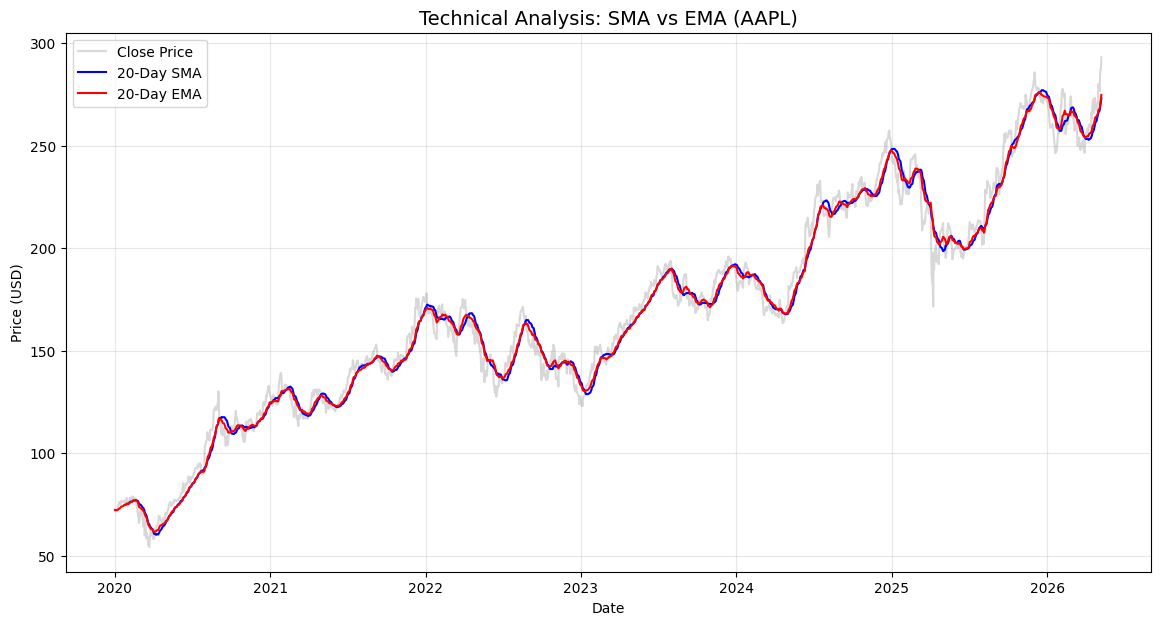

In [7]:
plt.figure(figsize=(14, 7))
plt.plot(df['Close'], label='Close Price', alpha=0.3, color='gray')
plt.plot(df['SMA_20'], label='20-Day SMA', color='blue', linewidth=1.5)
plt.plot(df['EMA_20'], label='20-Day EMA', color='red', linewidth=1.5)

plt.title("Technical Analysis: SMA vs EMA (AAPL)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)

# Save the plot for the report
plt.savefig("../visuals/aapl_technical_indicators1.png")
plt.show()

### Conclusion and Next Steps
The quantitative infrastructure is now fully prepared:
1. **Time-Series Integrity:** `ffill` logic is applied to handle weekend gaps.
2. **Feature Engineering:** SMA, EMA, and RSI are calculated to serve as inputs.
3. **Task 3 Strategy:** We are now ready to perform **Pearson Correlation** between these technical indicators and VADER sentiment scores.